In [2]:
# ============================================
# SECCIÓN 5. PCA FINAL E INTERPRETACIÓN
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# --------------------------------------------
# 1. Carga del dataset
# --------------------------------------------
df = sns.load_dataset("penguins").copy()

In [4]:
# --------------------------------------------
# 1. Selección de variables y limpieza
# --------------------------------------------
vars_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

vars_interpretacion = ["species", "island", "sex"]

df_pca = df[vars_numericas + vars_interpretacion].dropna(subset=vars_numericas).copy()

In [5]:
# --------------------------------------------
# 2. Estandarización
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[vars_numericas])

In [6]:
# --------------------------------------------
# 3. PCA final con 2 componentes
# --------------------------------------------
pca_final = PCA(n_components=2)
X_pca = pca_final.fit_transform(X_scaled)

In [7]:
# --------------------------------------------
# 4. DataFrame con scores de individuos
# --------------------------------------------
df_scores = df_pca.copy()
df_scores["CP1"] = X_pca[:, 0]
df_scores["CP2"] = X_pca[:, 1]

print("Primeras filas de las coordenadas factoriales:")
display(df_scores.head())

Primeras filas de las coordenadas factoriales:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species,island,sex,CP1,CP2
0,39.10,18.70,181.00,"3,750.00",Adelie,Torgersen,Male,-1.84,0.05
1,39.50,17.40,186.00,"3,800.00",Adelie,Torgersen,Female,-1.31,-0.43
2,40.30,18.00,195.00,"3,250.00",Adelie,Torgersen,Female,-1.37,-0.15
4,36.70,19.30,193.00,"3,450.00",Adelie,Torgersen,Female,-1.88,-0.00
5,39.30,20.60,190.00,"3,650.00",Adelie,Torgersen,Male,-1.91,0.83


In [8]:
# --------------------------------------------
# 5. Varianza explicada del PCA final
# --------------------------------------------
pca_final_summary = pd.DataFrame({
    "Componente": ["CP1", "CP2"],
    "Autovalor": pca_final.explained_variance_,
    "Varianza explicada": pca_final.explained_variance_ratio_,
    "Varianza acumulada": np.cumsum(pca_final.explained_variance_ratio_)
})

print("Resumen del PCA final:")
display(pca_final_summary)

Resumen del PCA final:


,Componente,Autovalor,Varianza explicada,Varianza acumulada
0,CP1,2.76,0.69,0.69
1,CP2,0.77,0.19,0.88


In [9]:
# --------------------------------------------
# 6. Cargas factoriales (loadings)
# --------------------------------------------
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=vars_numericas,
    columns=["CP1", "CP2"]
)

print("Cargas factoriales:")
display(loadings)

Cargas factoriales:


,CP1,CP2
bill_length_mm,0.46,0.60
bill_depth_mm,-0.40,0.80
flipper_length_mm,0.58,0.00
body_mass_g,0.55,0.08


In [10]:
# --------------------------------------------
# 7. Coordenadas de variables para círculo de correlaciones
# --------------------------------------------
# Escalado habitual para representar variables en el plano factorial
corr_vars = loadings.copy()
corr_vars["CP1"] = corr_vars["CP1"] * np.sqrt(pca_final.explained_variance_[0])
corr_vars["CP2"] = corr_vars["CP2"] * np.sqrt(pca_final.explained_variance_[1])

print("Coordenadas de variables en el plano factorial:")
display(corr_vars)

Coordenadas de variables en el plano factorial:


,CP1,CP2
bill_length_mm,0.76,0.53
bill_depth_mm,-0.67,0.70
flipper_length_mm,0.96,0.00
body_mass_g,0.91,0.07


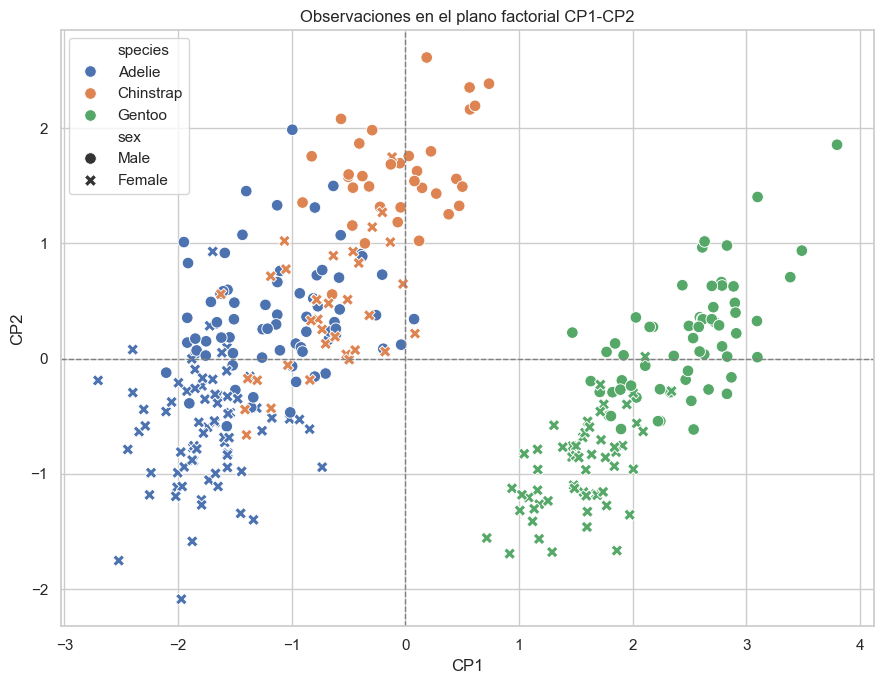

In [11]:
# --------------------------------------------
# 8. Gráfico de individuos en el plano CP1-CP2
# --------------------------------------------
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_scores,
    x="CP1",
    y="CP2",
    hue="species",
    style="sex",
    s=70
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Observaciones en el plano factorial CP1-CP2")
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.tight_layout()
plt.show()

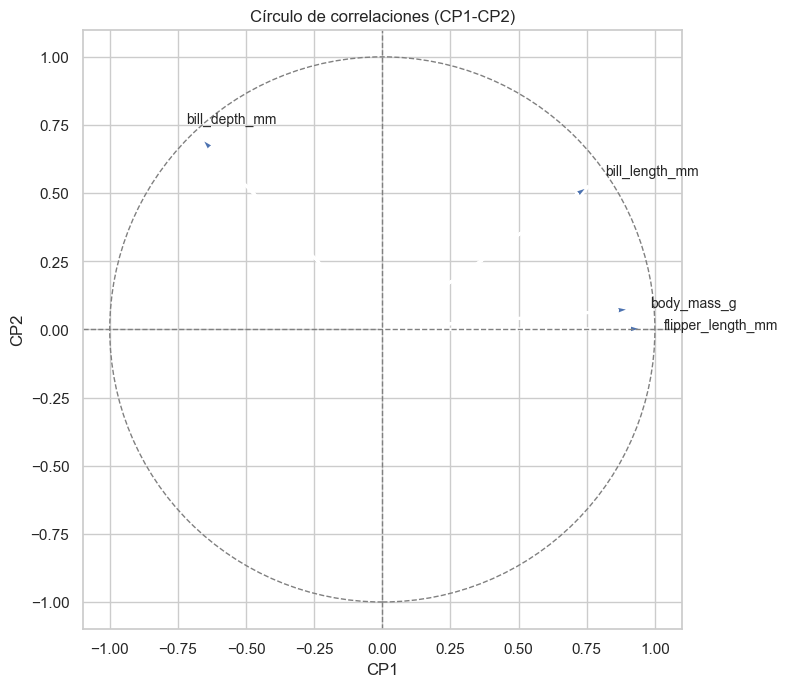

In [12]:
# --------------------------------------------
# 9. Círculo de correlaciones
# --------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# Círculo unitario
circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
ax.add_artist(circle)

# Flechas de variables
for var in corr_vars.index:
    x = corr_vars.loc[var, "CP1"]
    y = corr_vars.loc[var, "CP2"]
    
    ax.arrow(
        0, 0, x, y,
        head_width=0.03,
        head_length=0.05,
        linewidth=2,
        length_includes_head=True
    )
    ax.text(x * 1.08, y * 1.08, var, fontsize=10)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Círculo de correlaciones (CP1-CP2)")
ax.set_xlabel("CP1")
ax.set_ylabel("CP2")

plt.tight_layout()
plt.show()

In [13]:
# --------------------------------------------
# 10. Medias de componentes por especie
# --------------------------------------------
scores_por_especie = (
    df_scores.groupby("species")[["CP1", "CP2"]]
    .mean()
    .sort_values(by="CP1", ascending=False)
)

print("Medias de las componentes por especie:")
display(scores_por_especie)

Medias de las componentes por especie:


,CP1,CP2
species,,
Gentoo,2.01,-0.39
Chinstrap,-0.38,1.00
Adelie,-1.46,-0.13


In [14]:
# --------------------------------------------
# 11. Índice lineal conjunto basado en CP1
# --------------------------------------------
# CP1 como índice sintético de características físicas
df_scores["indice_fisico_cp1"] = df_scores["CP1"]

indice_especie = (
    df_scores.groupby("species")["indice_fisico_cp1"]
    .mean()
    .reset_index()
    .sort_values(by="indice_fisico_cp1", ascending=False)
)

print("Índice físico medio por especie (basado en CP1):")
display(indice_especie)

Índice físico medio por especie (basado en CP1):


,species,indice_fisico_cp1
2,Gentoo,2.01
1,Chinstrap,-0.38
0,Adelie,-1.46


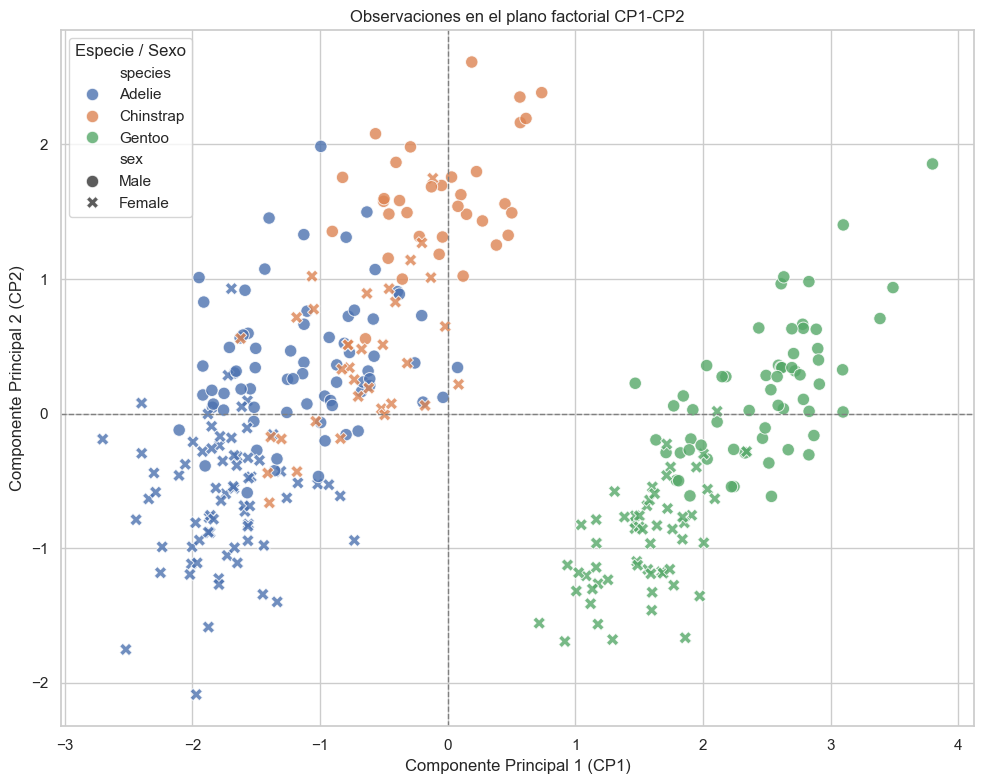

In [18]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_scores,
    x="CP1",
    y="CP2",
    hue="species",      # color por especie
    style="sex",        # forma por sexo (opcional pero recomendado)
    s=80,
    alpha=0.8
)

# Líneas en los ejes
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

# Títulos y etiquetas
plt.title("Observaciones en el plano factorial CP1-CP2")
plt.xlabel("Componente Principal 1 (CP1)")
plt.ylabel("Componente Principal 2 (CP2)")

plt.legend(title="Especie / Sexo")
plt.grid(True)

plt.tight_layout()

# Guardar figura para LaTeX
plt.savefig("figures/individuos_pca.png", dpi=300)

plt.show()

In [15]:
# --------------------------------------------
# 12. Tabla auxiliar con pesos del índice en variables estandarizadas
# --------------------------------------------
pesos_cp1 = pd.DataFrame({
    "Variable": vars_numericas,
    "Peso_CP1": pca_final.components_[0]
})

print("Pesos de CP1 para construir el índice lineal conjunto:")
display(pesos_cp1)

Pesos de CP1 para construir el índice lineal conjunto:


,Variable,Peso_CP1
0,bill_length_mm,0.46
1,bill_depth_mm,-0.40
2,flipper_length_mm,0.58
3,body_mass_g,0.55


In [16]:
# --------------------------------------------
# 13. Ejemplo explícito del índice lineal conjunto
# --------------------------------------------
print("Expresión aproximada del índice lineal conjunto (CP1):")
for var, peso in zip(vars_numericas, pca_final.components_[0]):
    print(f"{peso:.4f} * Z({var})")

Expresión aproximada del índice lineal conjunto (CP1):
0.4553 * Z(bill_length_mm)
-0.4003 * Z(bill_depth_mm)
0.5760 * Z(flipper_length_mm)
0.5484 * Z(body_mass_g)
